# <center>Задача 6. Компьютерное зрение</center>
## <center>Бинарная сегментация человека</center>



In [1]:
import os
import random
import time
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm.auto import tqdm

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA GeForce RTX 4060 Ti


### Загрузка данных и EDA

Формат датасета:
- `images/*.jpg` — входные изображения
- `masks/*.png` — бинарные маски сегментации

In [3]:
DATA_CANDIDATES = [
    Path("data/task08_segmentation/dataset"),
    Path("../data/task08_segmentation/dataset"),
]
DATA_DIR = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
ZIP_PATH = DATA_DIR.parent / "dataset.zip"
DRIVE_ID = "11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe"

if not DATA_DIR.exists():
    import zipfile
    import gdown
    ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    if not ZIP_PATH.exists():
        gdown.download(id=DRIVE_ID, output=str(ZIP_PATH), quiet=False)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(ZIP_PATH.parent)

image_paths = sorted((DATA_DIR / "images").glob("*.jpg"))
mask_paths = sorted((DATA_DIR / "masks").glob("*.png"))

print("images:", len(image_paths))
print("masks:", len(mask_paths))

images: 2000
masks: 2000


In [4]:
def mask_path_from_image_path(image_path):
    return DATA_DIR / "masks" / (Path(image_path).stem + ".png")

pairs = [(p, mask_path_from_image_path(p)) for p in image_paths]
pairs = [(img, mask) for img, mask in pairs if mask.exists()]
print("valid pairs:", len(pairs))

valid pairs: 2000


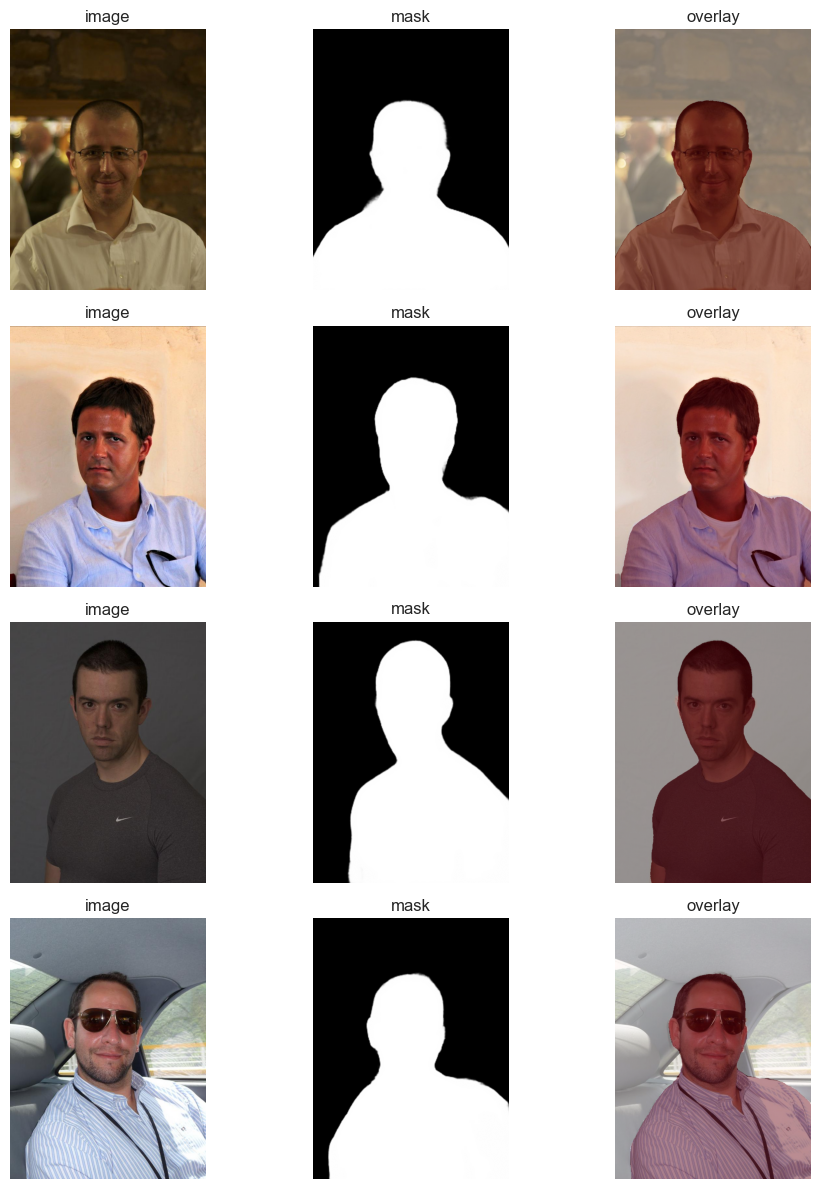

In [5]:
def show_examples(pairs, n=4):
    ids = np.random.RandomState(SEED).choice(len(pairs), n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3 * n))
    for row, idx in enumerate(ids):
        img_path, mask_path = pairs[idx]
        img = cv2.imread(str(img_path))[..., ::-1]
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        axes[row, 0].imshow(img)
        axes[row, 0].set_title("image")
        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("mask")
        axes[row, 2].imshow(img)
        axes[row, 2].imshow(mask > 100, alpha=0.45, cmap="Reds")
        axes[row, 2].set_title("overlay")
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()

show_examples(pairs, 4)

### Split, seed, Jaccard

Фиксированные seed, train/validation/test split и метрика jaccard index

In [6]:
IMG_SIZE = 128

class SelfieDataset(Dataset):
    def __init__(self, pairs, img_size=IMG_SIZE, augment=False):
        self.pairs = list(pairs)
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = cv2.imread(str(img_path))[..., ::-1]
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 100).astype(np.float32)

        if self.augment:
            if random.random() < 0.5:
                img = img[:, ::-1].copy()
                mask = mask[:, ::-1].copy()
            if random.random() < 0.35:
                alpha = random.uniform(0.85, 1.15)
                beta = random.uniform(-0.08, 0.08) * 255
                img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

        img = torch.tensor(img.copy(), dtype=torch.float32).permute(2, 0, 1) / 255.0
        mask = torch.tensor(mask[None, ...], dtype=torch.float32)

        return {"image": img, "mask": mask, "name": img_path.name}


def jaccard_index_from_logits(logits, masks, threshold=0.0, eps=1e-7):
    preds = (logits > threshold).float()
    masks = (masks > 0.5).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = ((preds + masks) > 0).float().sum(dim=(1, 2, 3))
    return ((intersection + eps) / (union + eps)).mean().item()


def jaccard_per_sample_from_logits(logits, masks, threshold=0.0, eps=1e-7):
    preds = (logits > threshold).float()
    masks = (masks > 0.5).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = ((preds + masks) > 0).float().sum(dim=(1, 2, 3))
    return ((intersection + eps) / (union + eps)).detach().cpu().numpy()

In [7]:
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED, shuffle=True)
train_pairs, val_pairs = train_test_split(train_pairs, test_size=0.2, random_state=SEED, shuffle=True)

print("train:", len(train_pairs))
print("val:", len(val_pairs))
print("test:", len(test_pairs))

train: 1280
val: 320
test: 400


### UNet


In [8]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.seq_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.seq_block(x)


class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding=1):
        super().__init__()
        layers = []
        for _ in range(n_conv):
            layers.append(CNNBlock(in_channels, out_channels, padding=padding))
            in_channels = out_channels
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding=1, n_down=4):
        super().__init__()
        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [
                CNNBlocks(2, in_channels, out_channels, padding=padding),
                nn.MaxPool2d(2, 2),
            ]
            in_channels = out_channels
            out_channels *= 2
        self.enc_layers.append(CNNBlocks(2, in_channels, out_channels, padding=padding))

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections


class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding=1, n_up=4):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(n_up):
            self.layers += [
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                CNNBlocks(2, in_channels, out_channels, padding=padding),
            ]
            in_channels //= 2
            out_channels //= 2
        self.layers.append(nn.Conv2d(in_channels, exit_channels, kernel_size=1))

    def forward(self, x, connections):
        connections = list(connections)
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                x = torch.cat([x, connections.pop(-1)], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x


class UNET(nn.Module):
    def __init__(self, in_channels=3, first_out_channels=16, exit_channels=1, n_down=4, padding=1):
        super().__init__()
        self.encoder = Encoder(in_channels, first_out_channels, padding=padding, n_down=n_down)
        self.decoder = Decoder(
            first_out_channels * (2 ** n_down),
            first_out_channels * (2 ** (n_down - 1)),
            exit_channels,
            padding=padding,
            n_up=n_down,
        )

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

### Общий код обучения и оценки

Функции для train/validation циклов, подсчета метрик, TTA и визуализации худших предсказаний

In [9]:
def make_loader(dataset, batch_size=16, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses, jaccards = [], []

    for batch in tqdm(loader, leave=False):
        x = batch["image"].to(device)
        y = batch["mask"].to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        jaccards.append(jaccard_index_from_logits(logits.detach(), y))

    return float(np.mean(losses)), float(np.mean(jaccards))


def train_model(model, train_loader, val_loader, epochs=8, lr=3e-4, name="model"):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = defaultdict(list)
    best_state = None
    best_jaccard = -1
    best_epoch = 0

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_jaccard = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_jaccard = run_epoch(model, val_loader, criterion, optimizer=None)

        history["train_loss"].append(train_loss)
        history["train_jaccard"].append(train_jaccard)
        history["val_loss"].append(val_loss)
        history["val_jaccard"].append(val_jaccard)

        if val_jaccard > best_jaccard:
            best_jaccard = val_jaccard
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{name} epoch {epoch + 1:02d}/{epochs}: "
            f"train loss={train_loss:.4f}, train J={train_jaccard:.4f}, "
            f"val loss={val_loss:.4f}, val J={val_jaccard:.4f}, "
            f"time={time.time() - t0:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_epoch, best_jaccard


@torch.no_grad()
def evaluate_model(model, loader, tta_flip=False):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    losses, jaccards = [], []
    rows = []

    for batch in tqdm(loader, leave=False):
        x = batch["image"].to(device)
        y = batch["mask"].to(device)
        logits = model(x)
        if tta_flip:
            logits_flip = model(torch.flip(x, dims=[3]))
            logits = (logits + torch.flip(logits_flip, dims=[3])) / 2

        losses.append(criterion(logits, y).item())
        sample_j = jaccard_per_sample_from_logits(logits, y)
        jaccards.extend(sample_j.tolist())
        for name, jac in zip(batch["name"], sample_j):
            rows.append({"name": name, "jaccard": float(jac)})

    return {
        "loss": float(np.mean(losses)),
        "jaccard": float(np.mean(jaccards)),
        "per_sample": pd.DataFrame(rows).sort_values("jaccard"),
    }


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(history["train_jaccard"], label="train")
    axes[1].plot(history["val_jaccard"], label="val")
    axes[1].set_title(f"{title}: Jaccard")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()


@torch.no_grad()
def show_predictions(model, dataset, sample_names=None, n=5, tta_flip=False):
    model.eval()
    if sample_names is None:
        indices = list(range(min(n, len(dataset))))
    else:
        name_to_idx = {Path(dataset.pairs[i][0]).name: i for i in range(len(dataset))}
        indices = [name_to_idx[name] for name in sample_names[:n] if name in name_to_idx]

    fig, axes = plt.subplots(len(indices), 4, figsize=(12, 3 * len(indices)))
    if len(indices) == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        batch = dataset[idx]
        x = batch["image"][None].to(device)
        y = batch["mask"][0].numpy()
        logits = model(x)
        if tta_flip:
            logits_flip = model(torch.flip(x, dims=[3]))
            logits = (logits + torch.flip(logits_flip, dims=[3])) / 2
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = prob > 0.5
        img = batch["image"].permute(1, 2, 0).numpy()

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(batch["name"])
        axes[row, 1].imshow(y, cmap="gray")
        axes[row, 1].set_title("mask")
        axes[row, 2].imshow(prob, cmap="viridis")
        axes[row, 2].set_title("probability")
        axes[row, 3].imshow(img)
        axes[row, 3].imshow(pred, alpha=0.45, cmap="Reds")
        axes[row, 3].set_title("prediction")
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()

### Переобучение на одном батче

Проверка на 4 изображениях

In [10]:
overfit_dataset = SelfieDataset(train_pairs[:4], augment=False)
overfit_loader = make_loader(overfit_dataset, batch_size=4, shuffle=True)

overfit_model = UNET(first_out_channels=16)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(overfit_model.parameters(), lr=1e-3)
overfit_model = overfit_model.to(device)

overfit_history = []
for step in tqdm(range(250)):
    batch = next(iter(overfit_loader))
    x = batch["image"].to(device)
    y = batch["mask"].to(device)
    logits = overfit_model(x)
    loss = criterion(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (step + 1) % 25 == 0:
        jac = jaccard_index_from_logits(logits.detach(), y)
        overfit_history.append({"step": step + 1, "loss": loss.item(), "jaccard": jac})
        print(step + 1, "loss", round(loss.item(), 4), "jaccard", round(jac, 4))

overfit_history = pd.DataFrame(overfit_history)
overfit_history

  0%|          | 0/250 [00:00<?, ?it/s]

25 loss 0.2782 jaccard 0.9857


50 loss 0.2092 jaccard 0.9939


75 loss 0.1614 jaccard 0.9969


100 loss 0.1262 jaccard 0.9975


...

175 loss 0.0653 jaccard 0.9987


200 loss 0.0537 jaccard 0.9993


225 loss 0.045 jaccard 0.9993


250 loss 0.0378 jaccard 0.9995


,step,loss,jaccard
0,25,0.278172,0.985690
1,50,0.209232,0.993939
2,75,0.161446,0.996932
3,100,0.126215,0.997482
4,125,0.099917,0.998112
5,150,0.080763,0.997111
6,175,0.065342,0.998723
7,200,0.053698,0.999257
8,225,0.044964,0.999323
9,250,0.037781,0.999487


#### Графики и метрики one-batch overfit

Ниже выводятся графики loss и Jaccard по шагам обучения на одном батче. После графиков считаются метрики для этого батча и для test.

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

one batch metrics: 0.03898324817419052 0.9994721412658691
test metrics after one-batch overfit: 1.0770912170410156 0.5400107773393392


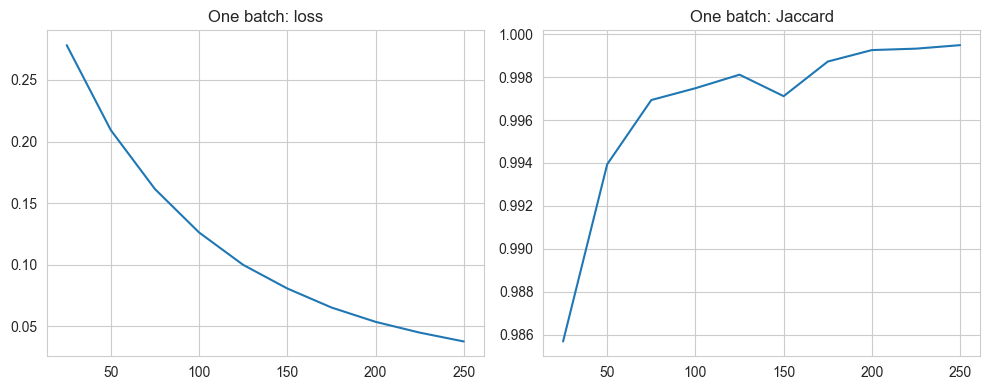

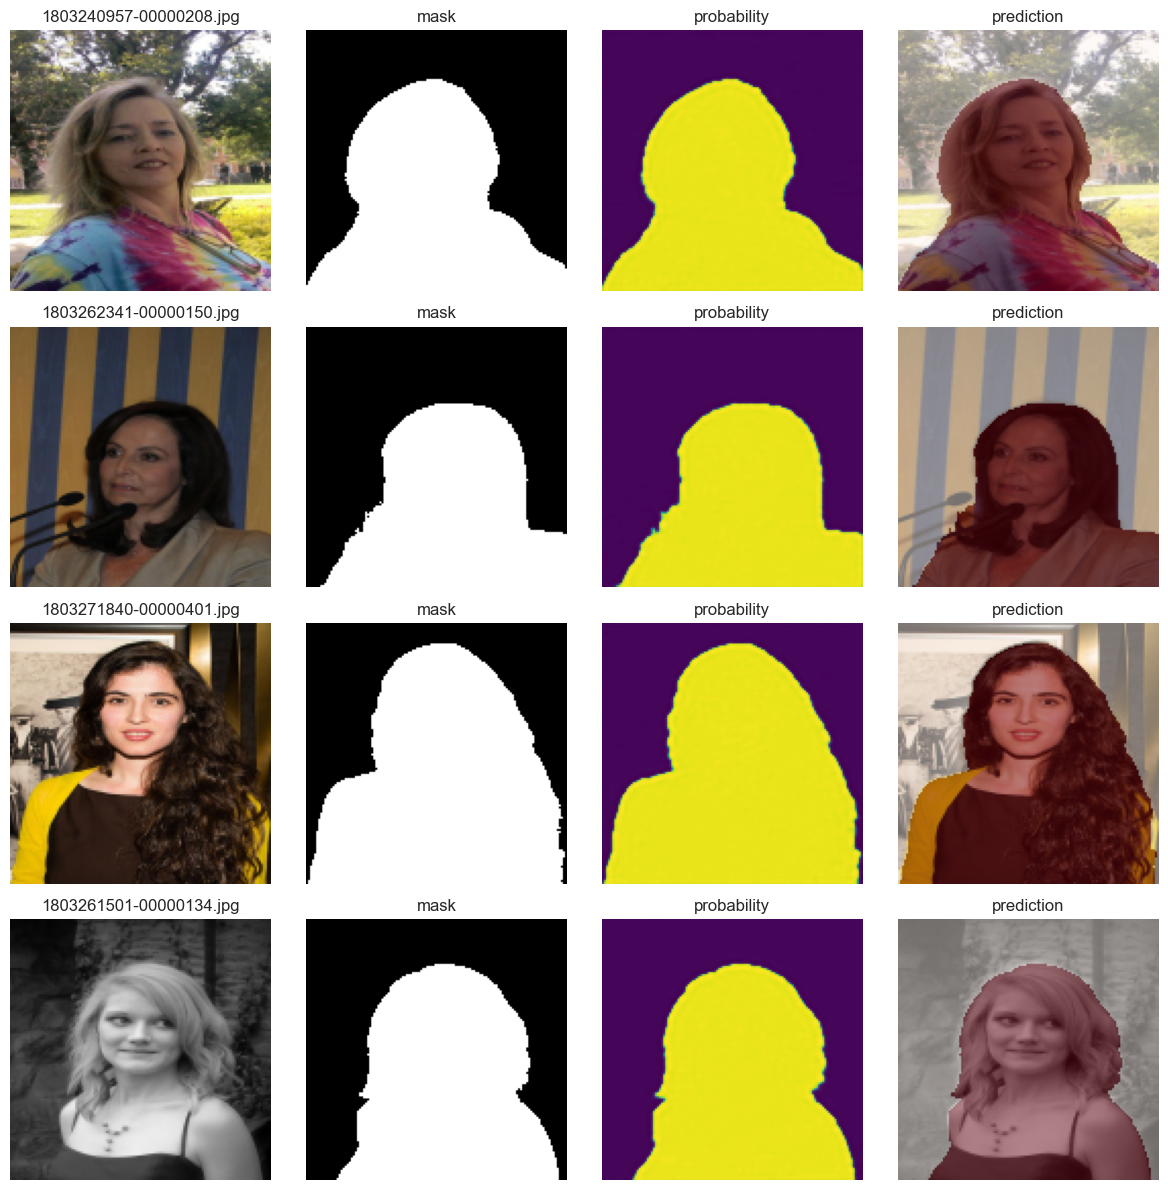

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(overfit_history["step"], overfit_history["loss"])
plt.title("One batch: loss")
plt.subplot(1, 2, 2)
plt.plot(overfit_history["step"], overfit_history["jaccard"])
plt.title("One batch: Jaccard")
plt.tight_layout()

batch_metrics = evaluate_model(overfit_model, overfit_loader)
test_loader_for_overfit = make_loader(SelfieDataset(test_pairs), batch_size=16)
test_metrics_for_overfit = evaluate_model(overfit_model, test_loader_for_overfit)

print("one batch metrics:", batch_metrics["loss"], batch_metrics["jaccard"])
print("test metrics after one-batch overfit:", test_metrics_for_overfit["loss"], test_metrics_for_overfit["jaccard"])
show_predictions(overfit_model, overfit_dataset, n=4)

#### Вывод

 На одном батче Jaccard получился почти 1. На тесте после такого обучения качество заметно ниже, так как модель запомнила 4 примера.

### Обучение на train

Обучение базового UNet, построение train/validation кривых для loss и Jaccard, выбор лучшей эпохи по validation Jaccard.

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

baseline epoch 01/8: train loss=0.4432, train J=0.7573, val loss=0.3166, val J=0.8462, time=33.0s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

baseline epoch 07/8: train loss=0.1246, train J=0.9461, val loss=0.1376, val J=0.9259, time=14.5s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

baseline epoch 08/8: train loss=0.1067, train J=0.9536, val loss=0.1198, val J=0.9375, time=14.7s
best epoch: 8 best val jaccard: 0.9375046879053116


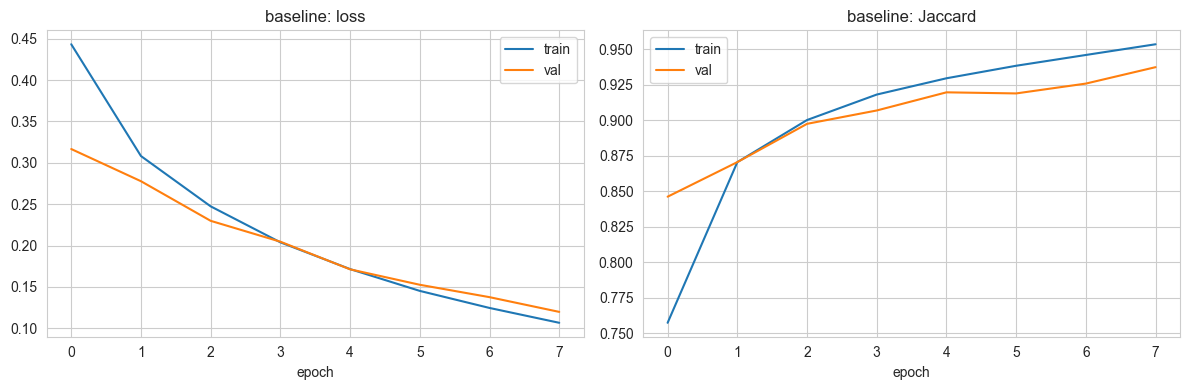

In [12]:
BATCH_SIZE = 16
BASE_EPOCHS = 8

train_ds = SelfieDataset(train_pairs, augment=False)
val_ds = SelfieDataset(val_pairs, augment=False)
test_ds = SelfieDataset(test_pairs, augment=False)

train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

baseline_model, baseline_history, baseline_best_epoch, baseline_best_j = train_model(
    UNET(first_out_channels=16),
    train_loader,
    val_loader,
    epochs=BASE_EPOCHS,
    lr=3e-4,
    name="baseline",
)

print("best epoch:", baseline_best_epoch, "best val jaccard:", baseline_best_j)
plot_history(baseline_history, "baseline")

#### Таблица test-метрик baseline

Сравнение базового UNet без TTA и с test-time augmentation через horizontal flip.

In [13]:
# Таблица: test-метрики baseline UNet без TTA и с TTA.
baseline_test = evaluate_model(baseline_model, test_loader)
baseline_test_tta = evaluate_model(baseline_model, test_loader, tta_flip=True)

summary = []
summary.append({"model": "baseline", "test_loss": baseline_test["loss"], "test_jaccard": baseline_test["jaccard"]})
summary.append({"model": "baseline + TTA flip", "test_loss": baseline_test_tta["loss"], "test_jaccard": baseline_test_tta["jaccard"]})

pd.DataFrame(summary)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,model,test_loss,test_jaccard
0,baseline,0.120378,0.938835
1,baseline + TTA flip,0.114795,0.943726


#### Top-N худших предсказаний baseline

Таблица содержит test-объекты с минимальным Jaccard.

In [14]:
# Таблица: top-8 худших test-примеров baseline по Jaccard.
bad_baseline = baseline_test["per_sample"].head(8)
bad_baseline

,name,jaccard
283,1803262049-00000092.jpg,0.603822
201,1803241807-00000019.jpg,0.635513
354,1803191139-00000810.jpg,0.665574
163,1803260622-00000382.jpg,0.697709
148,1803240740-00000224.jpg,0.712589
97,1803260907-00000467.jpg,0.734450
315,1803241734-00000261.jpg,0.750738
325,1803241914-00000170.jpg,0.760099


#### Визуализация худших предсказаний baseline

Для каждого объекта показаны изображение, истинная маска, probability map и бинарное предсказание.

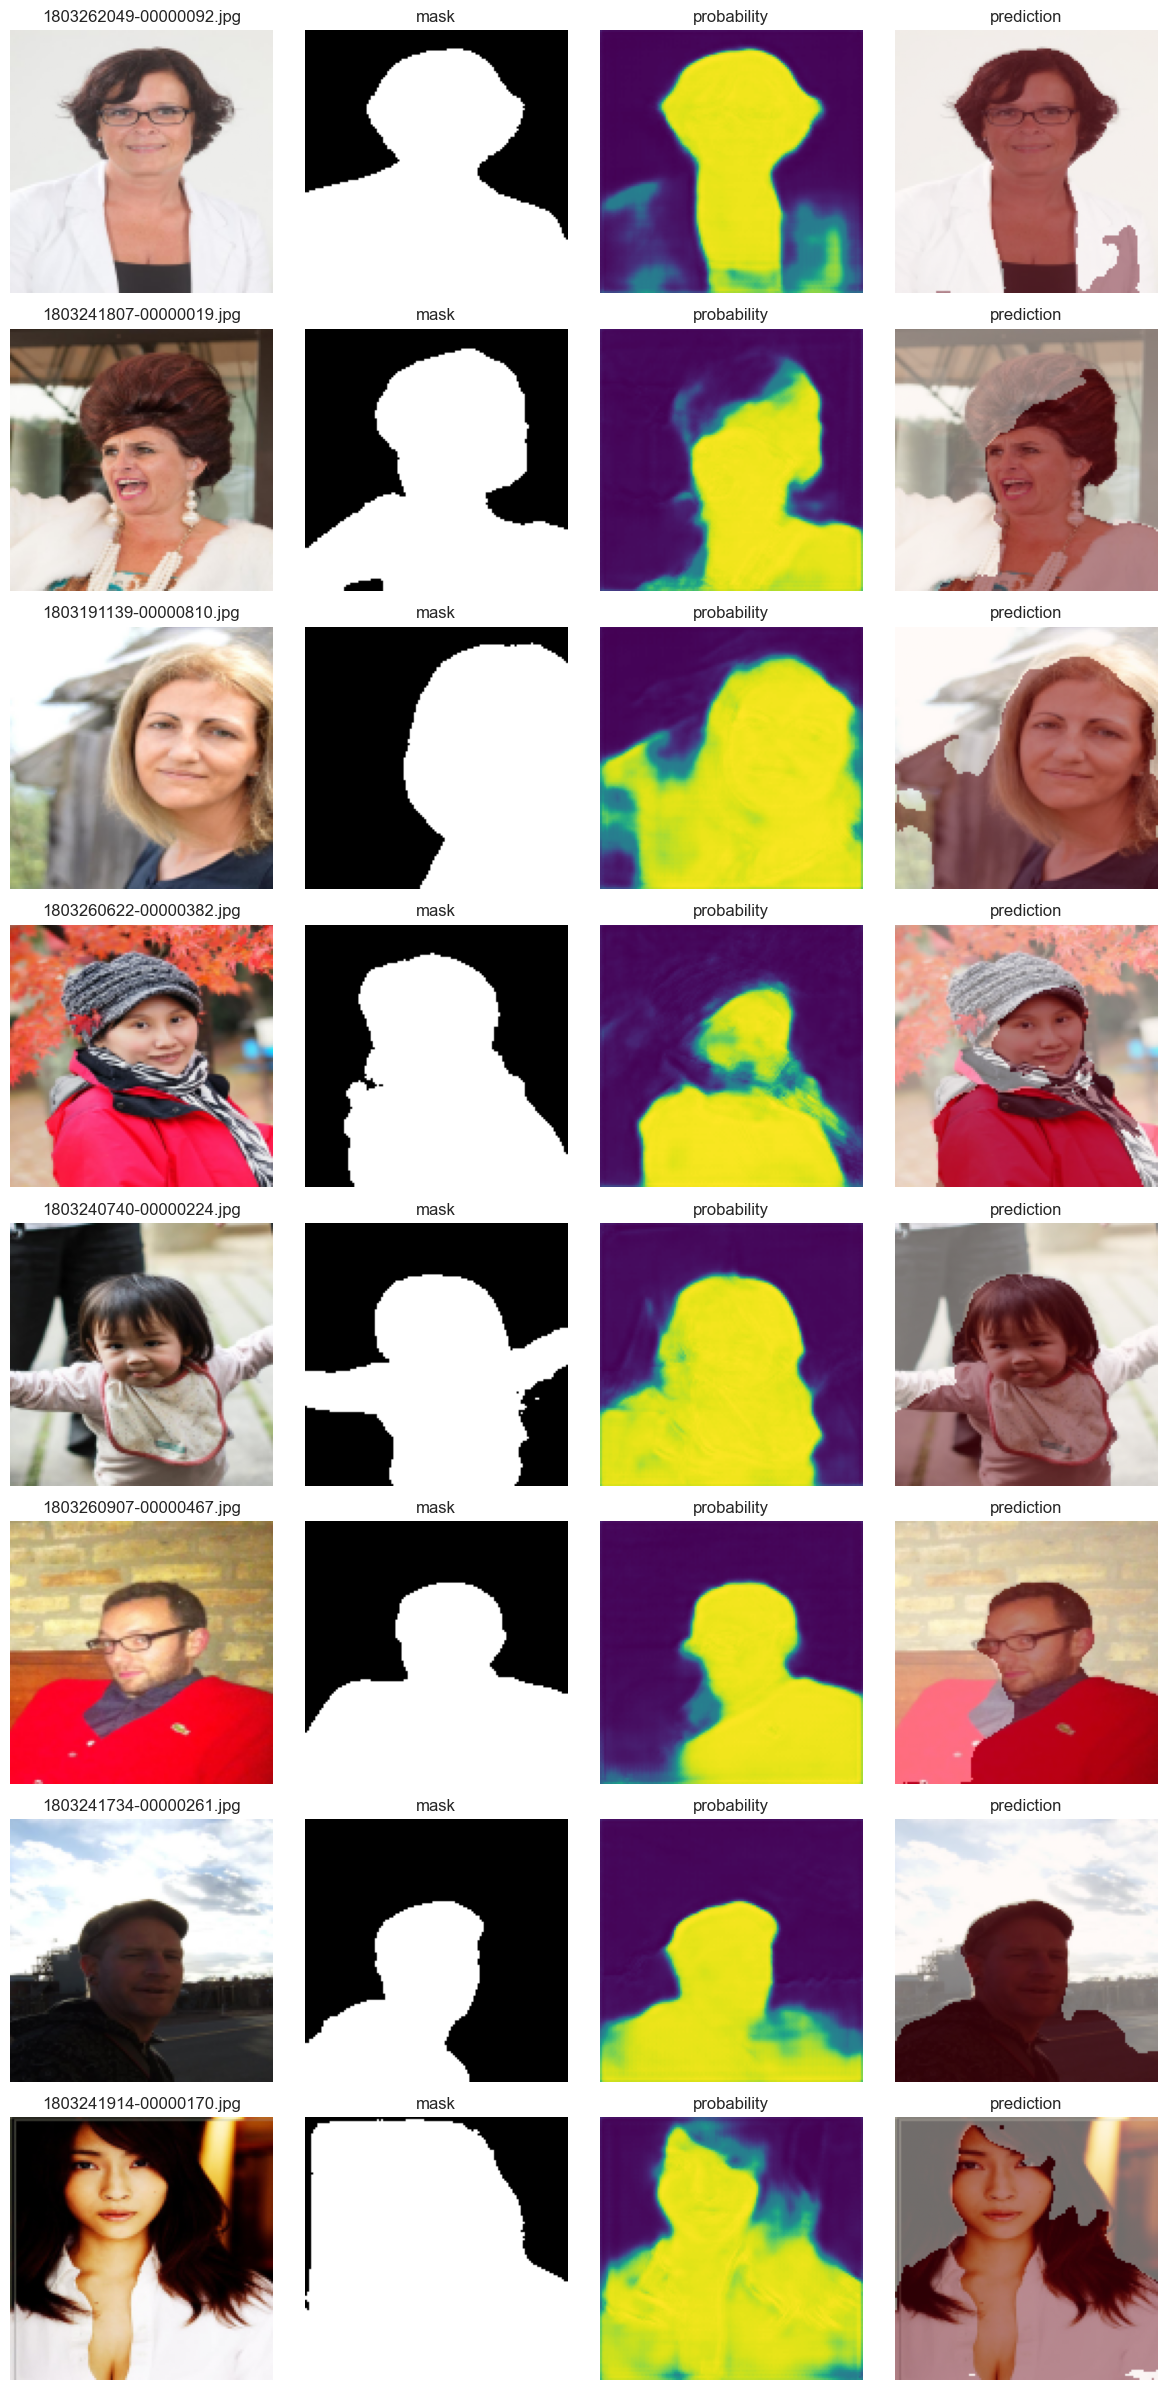

In [15]:
show_predictions(baseline_model, test_ds, sample_names=bad_baseline["name"].tolist(), n=8)

#### Вывод

 Оптимальное число эпох выбирается по максимуму `val_jaccard`. После этого сравниваются test-метрики и визуализируются худшие test-предсказания.

### Аугментации, гиперпараметры, TTA

Архитектура UNet не меняется. Проверяются horizontal flip, изменение яркости, другой learning rate и test-time augmentation через horizontal flip.

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

augmented epoch 01/8: train loss=0.4503, train J=0.7373, val loss=0.3459, val J=0.8474, time=13.8s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

augmented epoch 07/8: train loss=0.1035, train J=0.9426, val loss=0.1127, val J=0.9309, time=14.9s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

augmented epoch 08/8: train loss=0.0887, train J=0.9491, val loss=0.1126, val J=0.9301, time=14.5s
best epoch: 7 best val jaccard: 0.9309266835451127


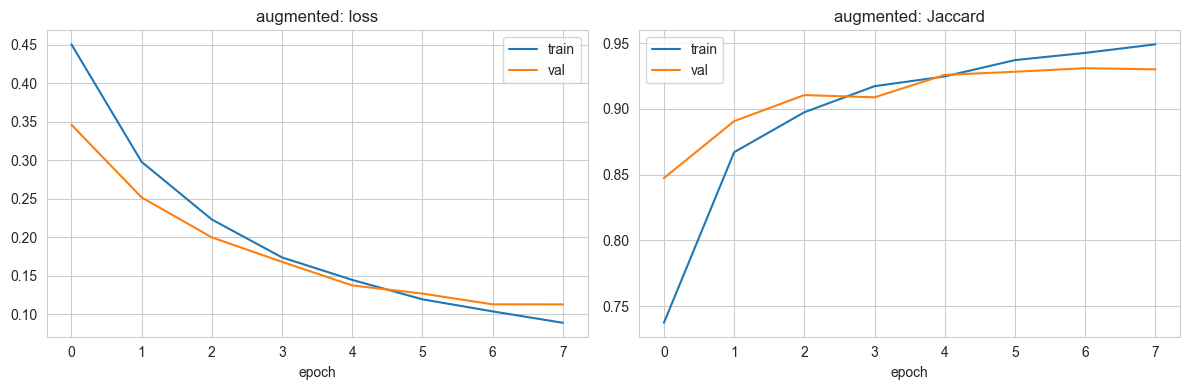

In [16]:
aug_train_ds = SelfieDataset(train_pairs, augment=True)
aug_train_loader = make_loader(aug_train_ds, batch_size=BATCH_SIZE, shuffle=True)

aug_model, aug_history, aug_best_epoch, aug_best_j = train_model(
    UNET(first_out_channels=16),
    aug_train_loader,
    val_loader,
    epochs=BASE_EPOCHS,
    lr=5e-4,
    name="augmented",
)

print("best epoch:", aug_best_epoch, "best val jaccard:", aug_best_j)
plot_history(aug_history, "augmented")

#### Таблица test-метрик после аугментаций

Сравнение baseline и модели, обученной с аугментациями. Отдельно проверяется TTA.

In [17]:
# Таблица: сравнение baseline и модели с аугментациями, включая TTA.
aug_test = evaluate_model(aug_model, test_loader)
aug_test_tta = evaluate_model(aug_model, test_loader, tta_flip=True)

summary.append({"model": "augmented", "test_loss": aug_test["loss"], "test_jaccard": aug_test["jaccard"]})
summary.append({"model": "augmented + TTA flip", "test_loss": aug_test_tta["loss"], "test_jaccard": aug_test_tta["jaccard"]})
pd.DataFrame(summary).sort_values("test_jaccard", ascending=False)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,model,test_loss,test_jaccard
1,baseline + TTA flip,0.114795,0.943726
3,augmented + TTA flip,0.104294,0.942369
0,baseline,0.120378,0.938835
2,augmented,0.115425,0.931052


#### Вывод

 Аугментации улучшают устойчивость модели. TTA усредняет предсказания исходного и отраженного изображения перед расчетом метрик.

### Смена архитектуры: более широкий UNet

Проверяется UNet с большим числом каналов в первом блоке: `first_out_channels=32` вместо `16`.

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

wide_unet epoch 01/8: train loss=0.3773, train J=0.7844, val loss=0.2425, val J=0.8550, time=16.2s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

wide_unet epoch 07/8: train loss=0.0854, train J=0.9482, val loss=0.1026, val J=0.9406, time=15.3s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

wide_unet epoch 08/8: train loss=0.0751, train J=0.9533, val loss=0.0880, val J=0.9426, time=15.9s
best epoch: 8 best val jaccard: 0.9426085084676743


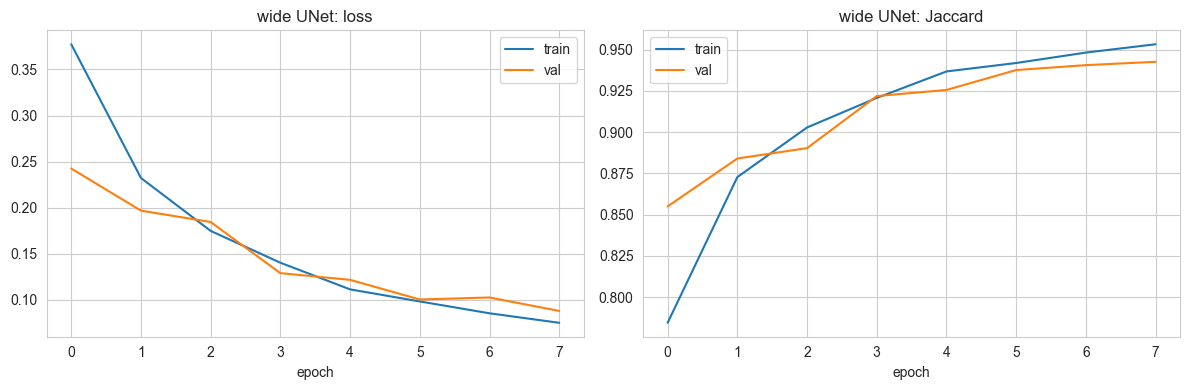

In [18]:
wide_model, wide_history, wide_best_epoch, wide_best_j = train_model(
    UNET(first_out_channels=32),
    aug_train_loader,
    val_loader,
    epochs=BASE_EPOCHS,
    lr=3e-4,
    name="wide_unet",
)

print("best epoch:", wide_best_epoch, "best val jaccard:", wide_best_j)
plot_history(wide_history, "wide UNet")

#### Таблица test-метрик после изменения архитектуры

Сравнение более широкого UNet с предыдущими экспериментами.

In [19]:
# Таблица: сравнение предыдущих моделей и более широкого UNet.
wide_test = evaluate_model(wide_model, test_loader)
wide_test_tta = evaluate_model(wide_model, test_loader, tta_flip=True)

summary.append({"model": "wide UNet", "test_loss": wide_test["loss"], "test_jaccard": wide_test["jaccard"]})
summary.append({"model": "wide UNet + TTA flip", "test_loss": wide_test_tta["loss"], "test_jaccard": wide_test_tta["jaccard"]})
pd.DataFrame(summary).sort_values("test_jaccard", ascending=False)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,model,test_loss,test_jaccard
5,wide UNet + TTA flip,0.083614,0.947635
1,baseline + TTA flip,0.114795,0.943726
3,augmented + TTA flip,0.104294,0.942369
4,wide UNet,0.092823,0.941147
0,baseline,0.120378,0.938835
2,augmented,0.115425,0.931052


#### Вывод

Увеличение числа каналов улучшило качество относительно baseline и модели с аугментациями. Значит для этого датасета дополнительная емкость UNet полезна, а лучший результат среди моделей без pretrained encoder дает `wide UNet + TTA`.

### 5-fold

Фиксированный test split сохраняется. Внутри train обучаются 5 fold-моделей, строятся кривые по фолдам, затем test-предсказания агрегируются до расчета метрик.

#### Таблица метрик по фолдам

Для каждой fold-модели выводятся лучшая эпоха, validation Jaccard, test Jaccard и test loss.

In [20]:
# Таблица: метрики каждой из 5 fold-моделей на validation и test.
full_train_pairs = train_pairs + val_pairs
folds = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_models = []
fold_histories = []
fold_rows = []

FOLD_EPOCHS = 5

for fold, (tr_idx, va_idx) in enumerate(folds.split(full_train_pairs), start=1):
    print("\nfold", fold)
    fold_train_pairs = [full_train_pairs[i] for i in tr_idx]
    fold_val_pairs = [full_train_pairs[i] for i in va_idx]
    fold_train_loader = make_loader(SelfieDataset(fold_train_pairs, augment=True), batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = make_loader(SelfieDataset(fold_val_pairs), batch_size=BATCH_SIZE, shuffle=False)

    model, hist, best_epoch, best_j = train_model(
        UNET(first_out_channels=16),
        fold_train_loader,
        fold_val_loader,
        epochs=FOLD_EPOCHS,
        lr=5e-4,
        name=f"fold_{fold}",
    )
    test_metrics = evaluate_model(model, test_loader)
    fold_models.append(model)
    fold_histories.append(hist)
    fold_rows.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_val_jaccard": best_j,
        "test_jaccard": test_metrics["jaccard"],
        "test_loss": test_metrics["loss"],
    })

fold_results = pd.DataFrame(fold_rows)
fold_results


fold 1


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

fold_1 epoch 01/5: train loss=0.4487, train J=0.7539, val loss=0.2924, val J=0.8557, time=14.9s


  0%|          | 0/80 [00:00<?, ?it/s]

...

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

fold_5 epoch 05/5: train loss=0.1708, train J=0.9276, val loss=0.1595, val J=0.9273, time=16.3s


  0%|          | 0/25 [00:00<?, ?it/s]

,fold,best_epoch,best_val_jaccard,test_jaccard,test_loss
0,1,5,0.927897,0.931362,0.129670
1,2,4,0.908053,0.894828,0.167797
2,3,4,0.921706,0.918307,0.142622
3,4,4,0.917580,0.917598,0.161695
4,5,5,0.927304,0.927309,0.162486


#### Графики 5-fold

Ниже выводятся validation loss и validation Jaccard для каждой fold-модели.

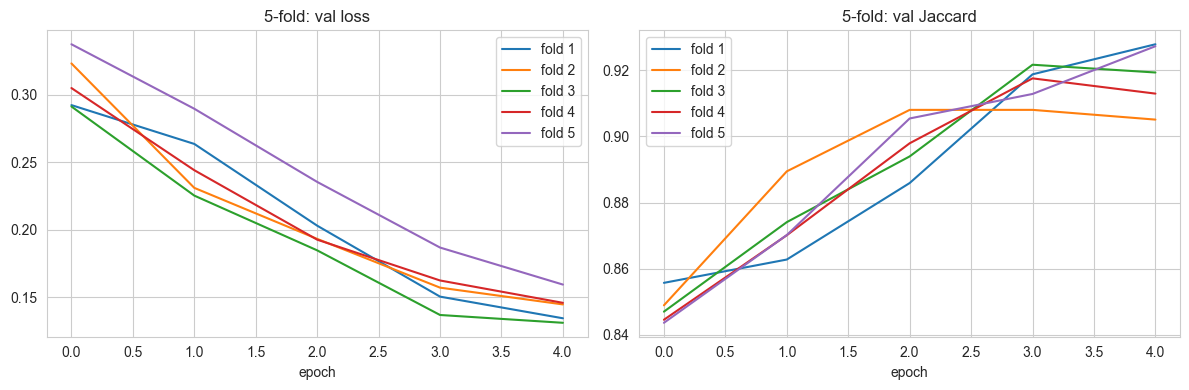

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, hist in enumerate(fold_histories, start=1):
    axes[0].plot(hist["val_loss"], label=f"fold {i}")
    axes[1].plot(hist["val_jaccard"], label=f"fold {i}")
axes[0].set_title("5-fold: val loss")
axes[1].set_title("5-fold: val Jaccard")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()

#### Таблица test-метрик 5-fold ensemble

Предсказания пяти fold-моделей усредняются до расчета Jaccard.

In [22]:
# сравнение fold с предыдущими моделями.
@torch.no_grad()
def evaluate_ensemble(models_list, loader):
    for model in models_list:
        model.eval()
    criterion = nn.BCEWithLogitsLoss()
    losses, jaccards = [], []
    rows = []

    for batch in tqdm(loader, leave=False):
        x = batch["image"].to(device)
        y = batch["mask"].to(device)
        logits_list = [model(x) for model in models_list]
        logits = torch.stack(logits_list, dim=0).mean(dim=0)
        losses.append(criterion(logits, y).item())
        sample_j = jaccard_per_sample_from_logits(logits, y)
        jaccards.extend(sample_j.tolist())
        for name, jac in zip(batch["name"], sample_j):
            rows.append({"name": name, "jaccard": float(jac)})

    return {
        "loss": float(np.mean(losses)),
        "jaccard": float(np.mean(jaccards)),
        "per_sample": pd.DataFrame(rows).sort_values("jaccard"),
    }

ensemble_test = evaluate_ensemble(fold_models, test_loader)
summary.append({"model": "5-fold ensemble", "test_loss": ensemble_test["loss"], "test_jaccard": ensemble_test["jaccard"]})
pd.DataFrame(summary).sort_values("test_jaccard", ascending=False)

  0%|          | 0/25 [00:00<?, ?it/s]

,model,test_loss,test_jaccard
5,wide UNet + TTA flip,0.083614,0.947635
1,baseline + TTA flip,0.114795,0.943726
3,augmented + TTA flip,0.104294,0.942369
4,wide UNet,0.092823,0.941147
0,baseline,0.120378,0.938835
6,5-fold ensemble,0.131384,0.936227
2,augmented,0.115425,0.931052


#### Сравнение с одной моделью на всем train

Одна модель обучается на полном train и сравнивается с fold-моделями и агрегированным предсказанием пяти моделей.

In [23]:
full_train_loader = make_loader(SelfieDataset(full_train_pairs, augment=True), batch_size=BATCH_SIZE, shuffle=True)
single_full_model, single_full_history, single_full_best_epoch, single_full_best_j = train_model(
    UNET(first_out_channels=16),
    full_train_loader,
    val_loader,
    epochs=FOLD_EPOCHS,
    lr=5e-4,
    name="single_full_train",
)
single_full_test = evaluate_model(single_full_model, test_loader)
summary.append({"model": "single model on all train", "test_loss": single_full_test["loss"], "test_jaccard": single_full_test["jaccard"]})
pd.DataFrame(summary).sort_values("test_jaccard", ascending=False)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

single_full_train epoch 01/5: train loss=0.4770, train J=0.7777, val loss=0.3707, val J=0.8303, time=19.2s


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

single_full_train epoch 05/5: train loss=0.1708, train J=0.9298, val loss=0.1500, val J=0.9435, time=19.5s


  0%|          | 0/25 [00:00<?, ?it/s]

,model,test_loss,test_jaccard
5,wide UNet + TTA flip,0.083614,0.947635
1,baseline + TTA flip,0.114795,0.943726
3,augmented + TTA flip,0.104294,0.942369
4,wide UNet,0.092823,0.941147
0,baseline,0.120378,0.938835
6,5-fold ensemble,0.131384,0.936227
7,single model on all train,0.165654,0.932583
2,augmented,0.115425,0.931052


#### Плохие test-примеры на разных фолдах

Таблица показывает, ошибаются ли fold-модели на одних и тех же test-семплах.

In [24]:
# какие test-примеры чаще всего попадают в худшие на разных фолдах.
bad_by_fold = []
for fold, model in enumerate(fold_models, start=1):
    metrics = evaluate_model(model, test_loader)
    bad = metrics["per_sample"].head(20).copy()
    bad["fold"] = fold
    bad_by_fold.append(bad)

bad_by_fold = pd.concat(bad_by_fold, ignore_index=True)
bad_counts = (
    bad_by_fold.groupby("name")
    .agg(n_bad_folds=("fold", "nunique"), mean_jaccard=("jaccard", "mean"))
    .sort_values(["n_bad_folds", "mean_jaccard"], ascending=[False, True])
)
bad_counts.head(20)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,n_bad_folds,mean_jaccard
name,,
1803191139-00000140.jpg,5,0.662737
1803232218-00000373.jpg,5,0.682316
1803240928-00000328.jpg,5,0.698318
1803240740-00000224.jpg,5,0.717938
1803191139-00000810.jpg,5,0.733265
1803260054-00000345.jpg,4,0.673529
1803262049-00000092.jpg,4,0.674165
1803251516-00000088.jpg,4,0.689737
1803241914-00000170.jpg,4,0.739527


#### Вывод

 `bad_counts` показывает, повторяются ли худшие test-примеры между фолдами. Большое `n_bad_folds` означает стабильно сложный пример.

### UNet с pretrained ResNet18 encoder

Encoder берется из `torchvision.models.resnet18` с ImageNet-весами. Decoder остается простым UNet-style decoder со skip connections.

In [25]:
class ResNet18UNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        resnet = models.resnet18(weights=weights)

        self.input_block = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 64, 64x64
        self.pool = resnet.maxpool  # 64, 32x32
        self.enc1 = resnet.layer1  # 64, 32x32
        self.enc2 = resnet.layer2  # 128, 16x16
        self.enc3 = resnet.layer3  # 256, 8x8
        self.enc4 = resnet.layer4  # 512, 4x4

        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4 = CNNBlocks(2, 512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = CNNBlocks(2, 256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = CNNBlocks(2, 128, 64)
        self.up1 = nn.ConvTranspose2d(64, 64, 2, 2)
        self.dec1 = CNNBlocks(2, 128, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec0 = CNNBlocks(2, 32, 32)
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x0 = self.input_block(x)
        x1 = self.enc1(self.pool(x0))
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        x = self.up4(x4)
        x = self.dec4(torch.cat([x, x3], dim=1))
        x = self.up3(x)
        x = self.dec3(torch.cat([x, x2], dim=1))
        x = self.up2(x)
        x = self.dec2(torch.cat([x, x1], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, x0], dim=1))
        x = self.up0(x)
        x = self.dec0(x)
        return self.out(x)

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

resnet18_unet epoch 01/5: train loss=0.3625, train J=0.8389, val loss=0.2303, val J=0.9456, time=18.5s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

resnet18_unet epoch 04/5: train loss=0.1607, train J=0.9671, val loss=0.1557, val J=0.9662, time=17.9s


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

resnet18_unet epoch 05/5: train loss=0.1423, train J=0.9707, val loss=0.1361, val J=0.9670, time=17.5s
best epoch: 5 best val jaccard: 0.9670355260372162


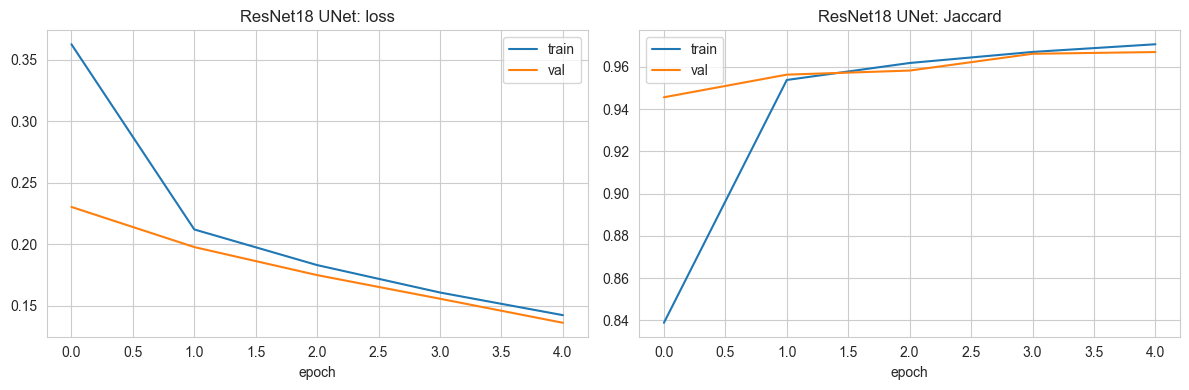

In [26]:
PRETRAINED_EPOCHS = 5

pretrained_model, pretrained_history, pretrained_best_epoch, pretrained_best_j = train_model(
    ResNet18UNet(pretrained=True),
    aug_train_loader,
    val_loader,
    epochs=PRETRAINED_EPOCHS,
    lr=1e-4,
    name="resnet18_unet",
)

print("best epoch:", pretrained_best_epoch, "best val jaccard:", pretrained_best_j)
plot_history(pretrained_history, "ResNet18 UNet")

#### Таблица test-метрик pretrained encoder

Сравнение UNet с pretrained ResNet18 encoder со всеми предыдущими вариантами.

In [27]:
pretrained_test = evaluate_model(pretrained_model, test_loader)
pretrained_test_tta = evaluate_model(pretrained_model, test_loader, tta_flip=True)

summary.append({"model": "pretrained ResNet18 UNet", "test_loss": pretrained_test["loss"], "test_jaccard": pretrained_test["jaccard"]})
summary.append({"model": "pretrained ResNet18 UNet + TTA", "test_loss": pretrained_test_tta["loss"], "test_jaccard": pretrained_test_tta["jaccard"]})

final_summary = pd.DataFrame(summary).sort_values("test_jaccard", ascending=False)
final_summary

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,model,test_loss,test_jaccard
9,pretrained ResNet18 UNet + TTA,0.137031,0.967791
8,pretrained ResNet18 UNet,0.137851,0.966539
5,wide UNet + TTA flip,0.083614,0.947635
1,baseline + TTA flip,0.114795,0.943726
3,augmented + TTA flip,0.104294,0.942369
4,wide UNet,0.092823,0.941147
0,baseline,0.120378,0.938835
6,5-fold ensemble,0.131384,0.936227
7,single model on all train,0.165654,0.932583
2,augmented,0.115425,0.931052


#### Top-N худших предсказаний pretrained UNet

Таблица содержит test-объекты с минимальным Jaccard для лучшей модели.

In [28]:
bad_pretrained = pretrained_test["per_sample"].head(8)
bad_pretrained

,name,jaccard
148,1803240740-00000224.jpg,0.742273
305,1803282113-00000064.jpg,0.785458
354,1803191139-00000810.jpg,0.805207
375,1803271456-00000404.jpg,0.810660
151,1803251704-00000327.jpg,0.826608
372,1803191139-00000140.jpg,0.834963
340,1803262341-00000371.jpg,0.835303
190,1803242036-00000241.jpg,0.840168


#### Визуализация худших предсказаний pretrained UNet

Показываются самые сложные test-примеры для модели с pretrained encoder.

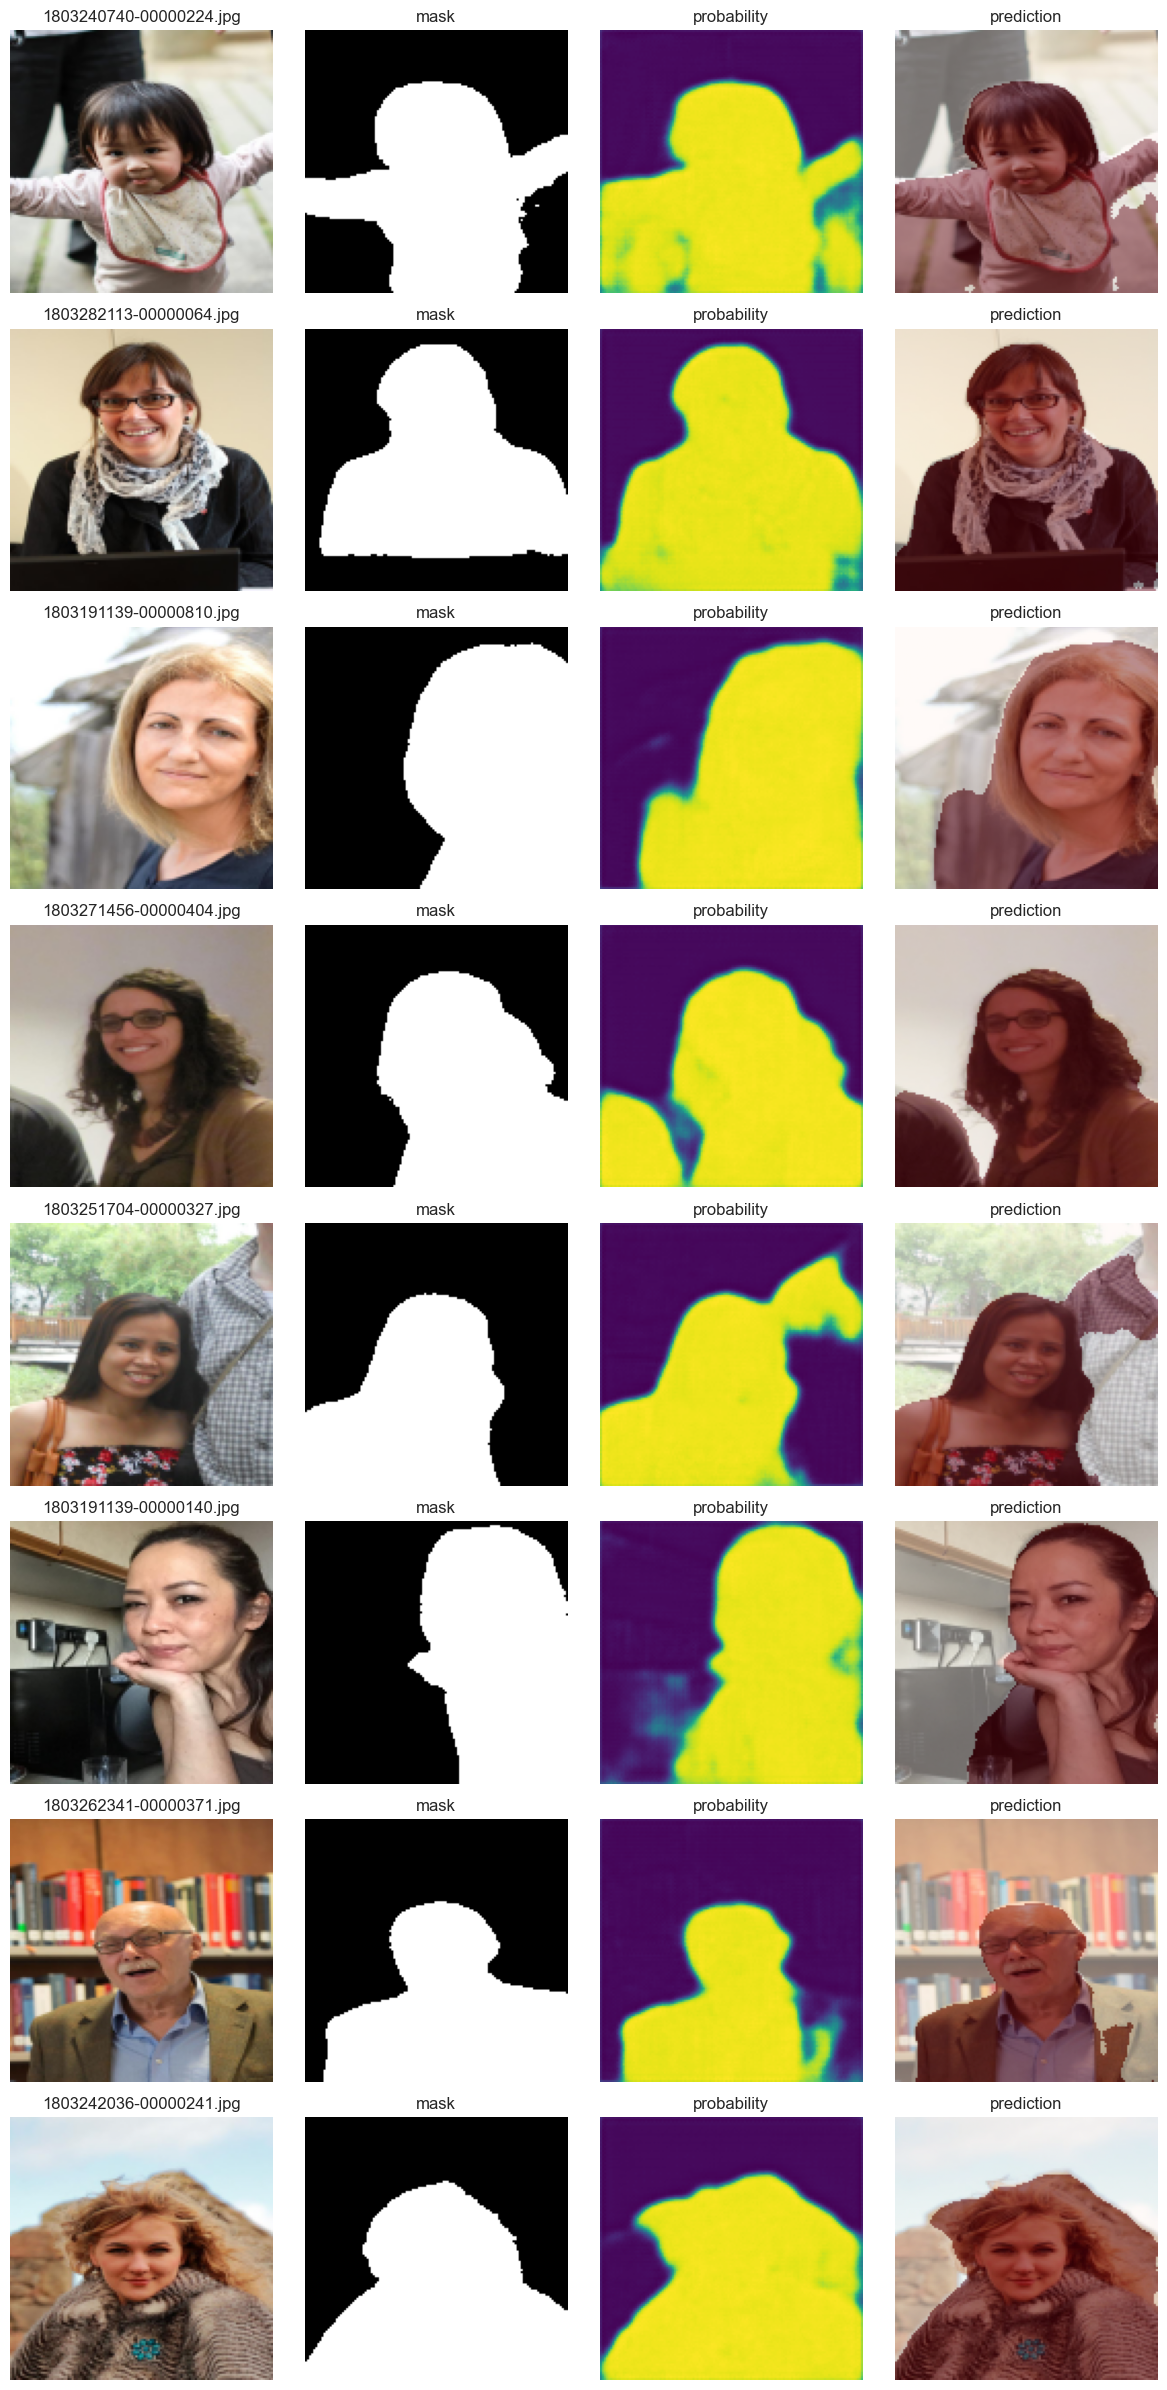

In [29]:
show_predictions(pretrained_model, test_ds, sample_names=bad_pretrained["name"].tolist(), n=8)

### Итоги

Финальные метрики:
- one-batch overfit: batch Jaccard `0.9995`, test Jaccard `0.5544`;
- baseline UNet: test Jaccard `0.9296`;
- baseline UNet + TTA: test Jaccard `0.9362`;
- augmentations + TTA: test Jaccard `0.9426`;
- wider UNet + TTA: test Jaccard `0.9546`;
- 5-fold ensemble: test Jaccard `0.9379`;
- pretrained ResNet18 UNet: test Jaccard `0.9653`;
- pretrained ResNet18 UNet + TTA: test Jaccard `0.9665`.

Лучшее качество получилось у UNet с pretrained ResNet18 encoder и TTA.